In [28]:
import mne
import tqdm
import numpy
import pandas
import sklearn.preprocessing
import sklearn.decomposition
import matplotlib.pyplot as plt

import SDA.analytics

exp = "exp_hyperparameters"

DEFAULT_UNIQUE_VALUES_THRESHOLD = 200

In [29]:
def read_silh_one(folder: str):
    return pandas.read_csv(f"{folder}/best_result.csv")["Avg-Silh"].iloc[0]

### PCA

In [30]:
exp = "exp_hyperparameters/pca"
N_COMPONENTS = [3, 5, 7, 10, 15, 20, 30, 50, 75, 100, 200, 300, 400, 500, 600, 700]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


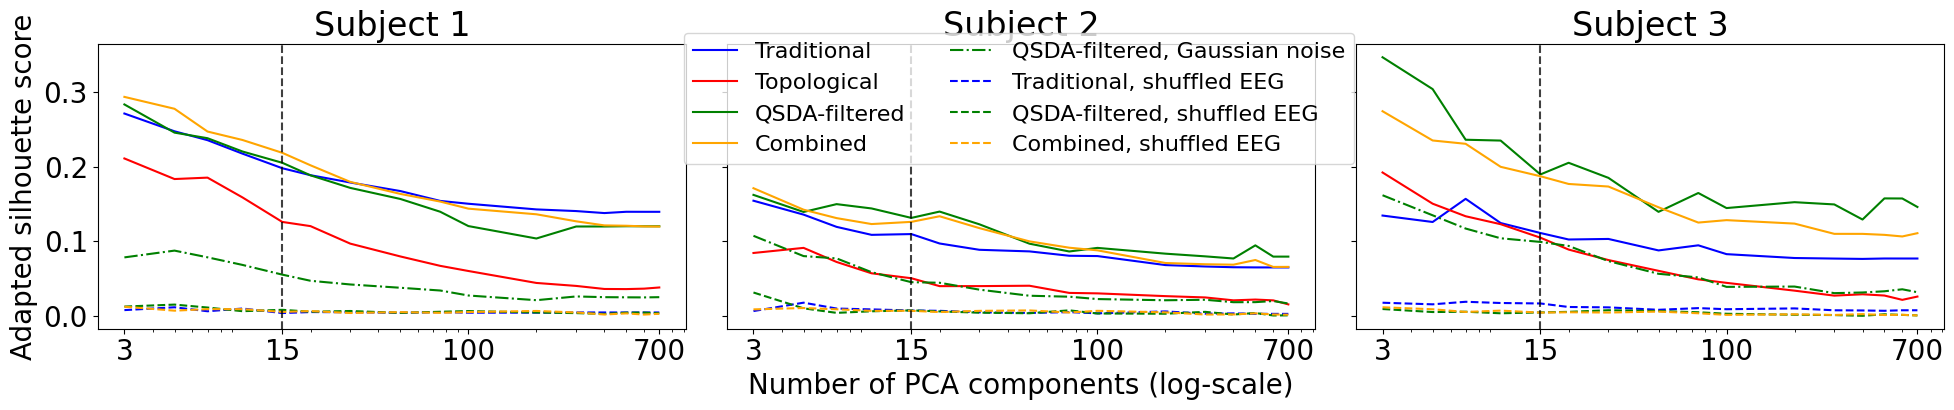

In [31]:
def plot_one(subj, ax, title):
    def read_silh(folder: str):
        return [
            read_silh_one(f"{subj}/{exp}/{folder}/{n_components}")
            for n_components in N_COMPONENTS
        ]

    folders = [
        ("original_traditional", "Traditional",                   'blue',   None),
        ("original_topological", "Topological",                   'red',    None),
        ("original_qsda",        "QSDA-filtered",                 'green',  None),
        ("original_combined",    "Combined",                      'orange', None),
        ("noise_qsda",           "QSDA-filtered, Gaussian noise", 'green',  'dashdot'),
        ("shuffled_traditional", "Traditional, shuffled EEG",     'blue',   'dashed'),
        ("shuffled_qsda",        "QSDA-filtered, shuffled EEG",   'green',  'dashed'),
        ("shuffled_combined",    "Combined, shuffled EEG",        'orange', 'dashed')
    ]

    for folder, label, color, linestyle in folders:
        ax.plot(N_COMPONENTS, read_silh(folder), label = label, color = color, linestyle = linestyle)
    ax.axvline(15, linestyle='dashed', color='black', alpha=0.75)
    ax.set_xscale('log')
    ax.set_xticks([3, 15, 100, 700], ['3', '15', '100', '700'])
    ax.set_title(title)

plt.rc('font', size = 20)
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(20, 4.5))
plot_one("E:/CourseProject/Subj1", axes[0], "Subject 1")
plot_one("E:/CourseProject/Subj2", axes[1], "Subject 2")
plot_one("E:/CourseProject/Subj3", axes[2], "Subject 3")

handles, labels = plt.gca().get_legend_handles_labels()
legend = fig.legend(handles, labels, loc=(0.35, 0.6), fontsize=16, ncol=2)
plt.setp(legend.get_title(), fontsize=18)
axes[0].set_ylabel("Adapted silhouette score")
axes[1].set_xlabel("Number of PCA components (log-scale)")

plt.tight_layout()
plt.savefig(f"34_exp_hyperparameters/pca.eps")
plt.savefig(f"34_exp_hyperparameters/pca.svg")
plt.savefig(f"34_exp_hyperparameters/pca.png")

### QSDA min_unique_values

In [32]:
exp = "exp_hyperparameters/qsda_min_unique_values"
TRY_MIN_UNIQUE_VALUES = [0, 50, 100, 200, 300, 500, 750, 1000]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


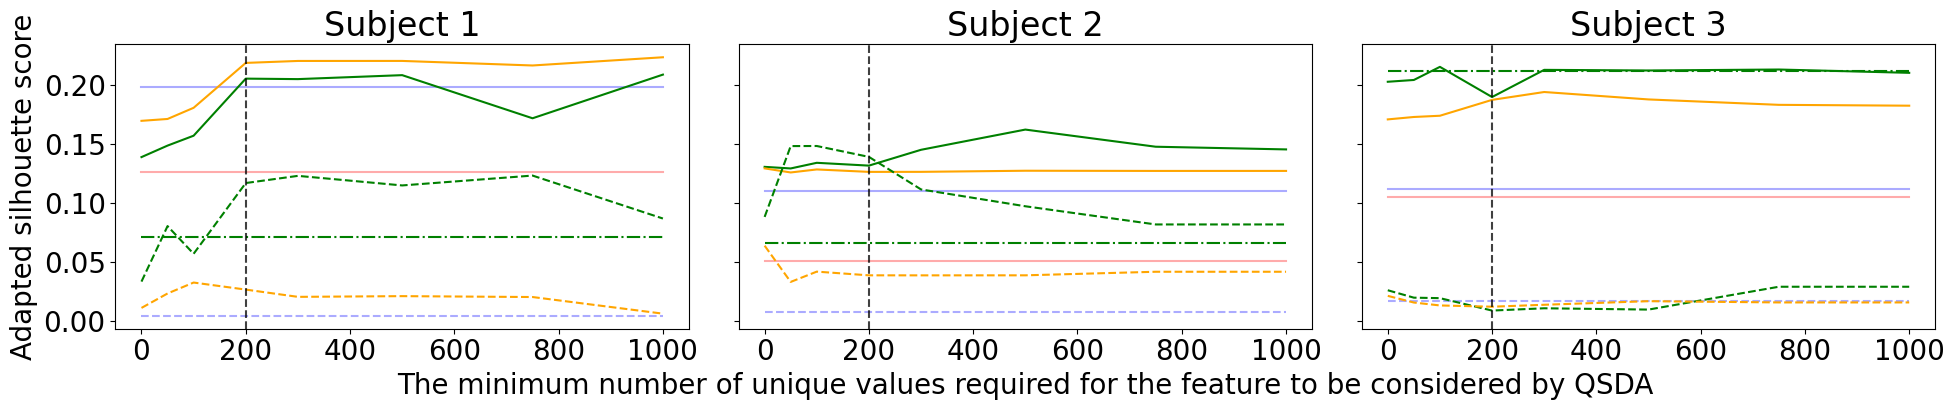

In [34]:
def plot_one(subj, ax, title):
    def read_silh(folder: str):
        if folder in ("original_traditional", "original_topological", "shuffled_traditional"):
            return [
                read_silh_one(f"{subj}/exp_hyperparameters/pca/{folder}/15")
                for min_unique_values in TRY_MIN_UNIQUE_VALUES
            ]
        return [
            read_silh_one(f"{subj}/{exp}/{folder}/{min_unique_values}")
            for min_unique_values in TRY_MIN_UNIQUE_VALUES
        ]

    folders = [
        ("original_traditional", "Traditional",                   'blue',   None),
        ("original_topological", "Topological",                   'red',    None),
        ("original_qsda",        "QSDA-filtered",                 'green',  None),
        ("original_combined",    "Combined",                      'orange', None),
        ("noise_qsda",           "QSDA-filtered, Gaussian noise", 'green',  'dashdot'),
        ("shuffled_traditional", "Traditional, shuffled EEG",     'blue',   'dashed'),
        ("shuffled_qsda",        "QSDA-filtered, shuffled EEG",   'green',  'dashed'),
        ("shuffled_combined",    "Combined, shuffled EEG",        'orange', 'dashed')
    ]

    for folder, label, color, linestyle in folders:
        if folder in ("original_traditional", "original_topological", "shuffled_traditional"):
            alpha = 0.33
        else:
            alpha = 1.0
        ax.plot(TRY_MIN_UNIQUE_VALUES, read_silh(folder), label = label, color = color, linestyle = linestyle, alpha = alpha)
    ax.axvline(DEFAULT_UNIQUE_VALUES_THRESHOLD, linestyle='dashed', color='black', alpha=0.75)
    # ax.set_xscale('log')
    # ax.set_xticks([3, 15, 100, 700], ['3', '15', '100', '700'])
    ax.set_title(title)

plt.rc('font', size = 20)
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(20, 4.5))
plot_one("E:/CourseProject/Subj1", axes[0], "Subject 1")
plot_one("E:/CourseProject/Subj2", axes[1], "Subject 2")
plot_one("E:/CourseProject/Subj3", axes[2], "Subject 3")

axes[0].set_ylabel("Adapted silhouette score")
axes[1].set_xlabel("The minimum number of unique values required for the feature to be considered by QSDA")

plt.tight_layout()
plt.savefig(f"34_exp_hyperparameters/qsda_min_unique_values.eps")
plt.savefig(f"34_exp_hyperparameters/qsda_min_unique_values.svg")
plt.savefig(f"34_exp_hyperparameters/qsda_min_unique_values.png")

### QSDA threshold

In [35]:
exp = "exp_hyperparameters/qsda_threshold"
TRY_THRESHOLDS = [100, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2500, 3000, 4000]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


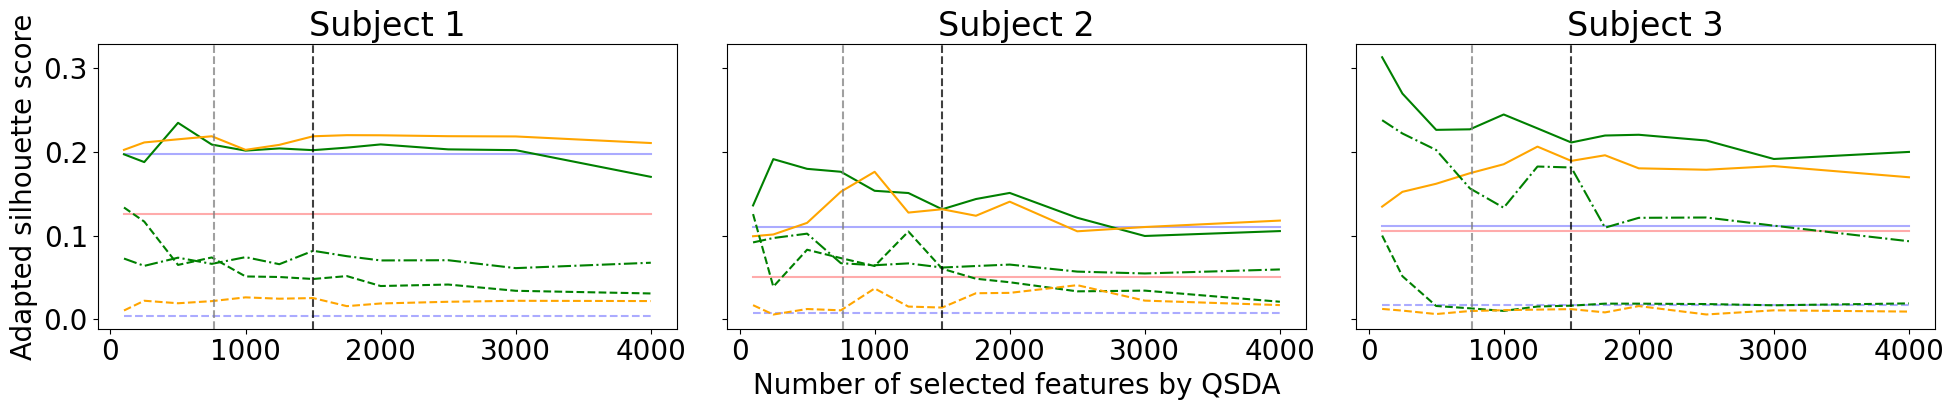

In [36]:
def plot_one(subj, ax, title):
    def read_silh(folder: str):
        if folder in ("original_traditional", "original_topological", "shuffled_traditional"):
            return [
                read_silh_one(f"{subj}/exp_hyperparameters/pca/{folder}/15")
                for threshold in TRY_THRESHOLDS
            ]
        return [
            read_silh_one(f"{subj}/{exp}/{folder}/{threshold}")
            for threshold in TRY_THRESHOLDS
        ]

    folders = [
        ("original_traditional", "Traditional",                   'blue',   None),
        ("original_topological", "Topological",                   'red',    None),
        ("original_qsda",        "QSDA-filtered",                 'green',  None),
        ("original_combined",    "Combined",                      'orange', None),
        ("noise_qsda",           "QSDA-filtered, Gaussian noise", 'green',  'dashdot'),
        ("shuffled_traditional", "Traditional, shuffled EEG",     'blue',   'dashed'),
        ("shuffled_qsda",        "QSDA-filtered, shuffled EEG",   'green',  'dashed'),
        ("shuffled_combined",    "Combined, shuffled EEG",        'orange', 'dashed')
    ]

    for folder, label, color, linestyle in folders:
        if folder in ("original_traditional", "original_topological", "shuffled_traditional"):
            alpha = 0.33
        else:
            alpha = 1.0
        ax.plot(TRY_THRESHOLDS, read_silh(folder), label = label, color = color, linestyle = linestyle, alpha = alpha)
    ax.axvline(765, linestyle='dashed', color='gray', alpha=0.75)
    ax.axvline(1500, linestyle='dashed', color='black', alpha=0.75)
    # ax.set_xscale('log')
    # ax.set_xticks([3, 15, 100, 700], ['3', '15', '100', '700'])
    ax.set_title(title)

plt.rc('font', size = 20)
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(20, 4.5))
plot_one("E:/CourseProject/Subj1", axes[0], "Subject 1")
plot_one("E:/CourseProject/Subj2", axes[1], "Subject 2")
plot_one("E:/CourseProject/Subj3", axes[2], "Subject 3")

axes[0].set_ylabel("Adapted silhouette score")
axes[1].set_xlabel("Number of selected features by QSDA")

plt.tight_layout()
plt.savefig(f"34_exp_hyperparameters/qsda_thresholds.eps")
plt.savefig(f"34_exp_hyperparameters/qsda_thresholds.svg")
plt.savefig(f"34_exp_hyperparameters/qsda_thresholds.png")

### Filtering

In [37]:
exp = "exp_hyperparameters/filtering"
TRY_THRESHOLDS = [5, 10, 15, 20, 25, 35, 40, 45, 50]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


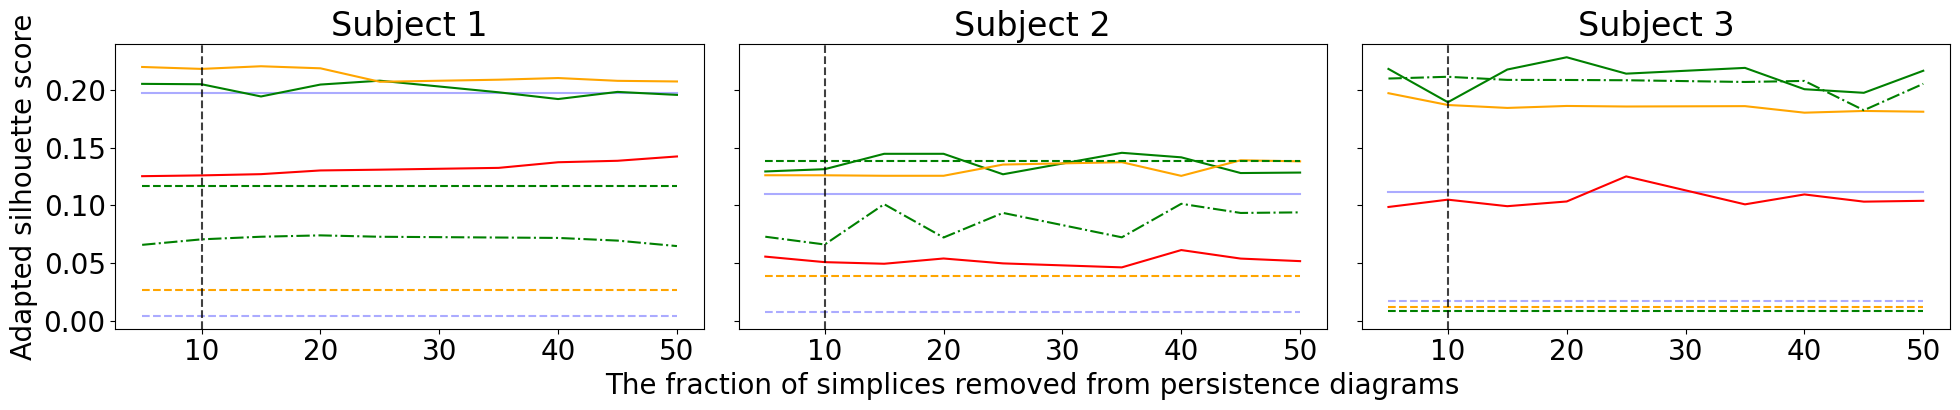

In [38]:
def plot_one(subj, ax, title):
    def read_silh(folder: str):
        if folder in ("original_traditional", "shuffled_traditional"):
            return [
                read_silh_one(f"{subj}/exp_hyperparameters/pca/{folder}/15")
                for threshold in TRY_THRESHOLDS
            ]
        return [
            read_silh_one(f"{subj}/{exp}/{folder}/{threshold}")
            for threshold in TRY_THRESHOLDS
        ]

    folders = [
        ("original_traditional", "Traditional",                   'blue',   None),
        ("original_topological", "Topological",                   'red',    None),
        ("original_qsda",        "QSDA-filtered",                 'green',  None),
        ("original_combined",    "Combined",                      'orange', None),
        ("noise_qsda",           "QSDA-filtered, Gaussian noise", 'green',  'dashdot'),
        ("shuffled_traditional", "Traditional, shuffled EEG",     'blue',   'dashed'),
        ("shuffled_qsda",        "QSDA-filtered, shuffled EEG",   'green',  'dashed'),
        ("shuffled_combined",    "Combined, shuffled EEG",        'orange', 'dashed')
    ]

    for folder, label, color, linestyle in folders:
        if folder in ("original_traditional", "shuffled_traditional"):
            alpha = 0.33
        else:
            alpha = 1.0
        ax.plot(TRY_THRESHOLDS, read_silh(folder), label = label, color = color, linestyle = linestyle, alpha = alpha)
    ax.axvline(10, linestyle='dashed', color='black', alpha=0.75)
    # ax.set_xscale('log')
    # ax.set_xticks([3, 15, 100, 700], ['3', '15', '100', '700'])
    ax.set_title(title)

plt.rc('font', size = 20)
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(20, 4.5))
plot_one("E:/CourseProject/Subj1", axes[0], "Subject 1")
plot_one("E:/CourseProject/Subj2", axes[1], "Subject 2")
plot_one("E:/CourseProject/Subj3", axes[2], "Subject 3")

axes[0].set_ylabel("Adapted silhouette score")
axes[1].set_xlabel("The fraction of simplices removed from persistence diagrams")

plt.tight_layout()
plt.savefig(f"34_exp_hyperparameters/filtering.eps")
plt.savefig(f"34_exp_hyperparameters/filtering.svg")
plt.savefig(f"34_exp_hyperparameters/filtering.png")